# HRN Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

It compares:

- HRN baselines

It uses the same analysis utilities and plotting layout as `hcast_analysis.ipynb`, with run names changed to HRN.

In [101]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir()), cwd)
notebook_utils_dir = repo_root / 'notebooks' / 'utils'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HRNAnalysis,
    HCastAnalysisConfig as HRNAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [102]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HRN_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'hrn_{dataset}', 'label': 'HRN baseline'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}

MANUAL_RUNS = [
    *[
        {'run_dir': f'hrn_{dataset}_level_marginal_lex_coarse_first',
            'label': f'HRN level_marginal lex coarse_first'}
        for dataset in HRN_DATASETS
    ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]

In [103]:
config = HRNAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HRNAnalysis.from_config(config)
analysis.print_run_summary()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_cifar100_level_marginal_lex_coarse_first
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_aircraft_level_marginal_lex_coarse_first
Baseline-only datasets (no selected comparison runs): cifar-100, fgvc-aircraft
Skipping missing baseline run: /scratch/g.saggini1/outputs/hrn_cifar100
[cub-200-2011] HRN baseline: epochs=200, best_td_epoch=130.33333333333334, best_ind_epoch=168.0, baseline, seeds=[0, 1, 2]
[cub-200-2011] HRN level_marginal lex coarse_first: epochs=200, best_td_epoch=91.0, best_ind_epoch=59.0, seeds=[0, 1]
[fgvc-aircraft] HRN baseline: epochs=200, best_td_epoch=172.0, best_ind_epoch=190.33333333333334, baseline, seeds=[0, 1, 2]


## HRN Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

This makes decoder dependence visible when comparing HRN runs.

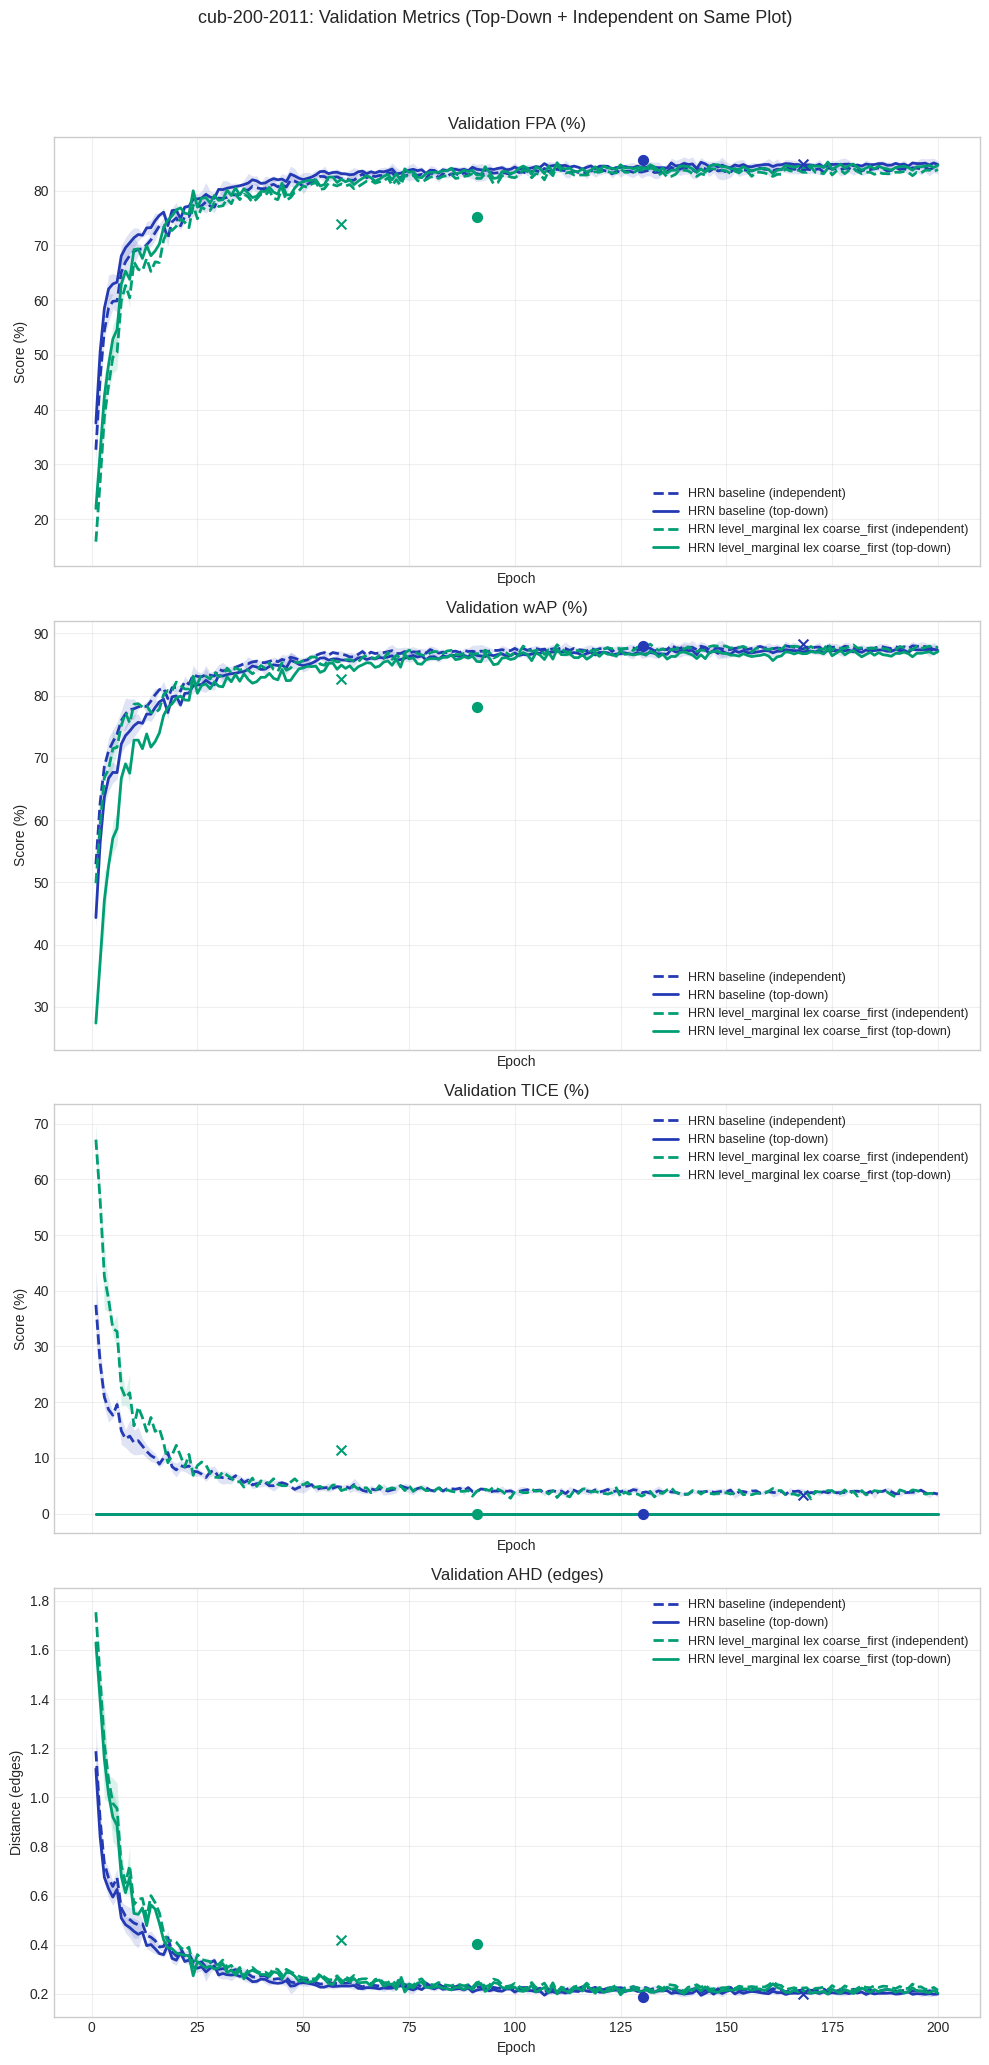

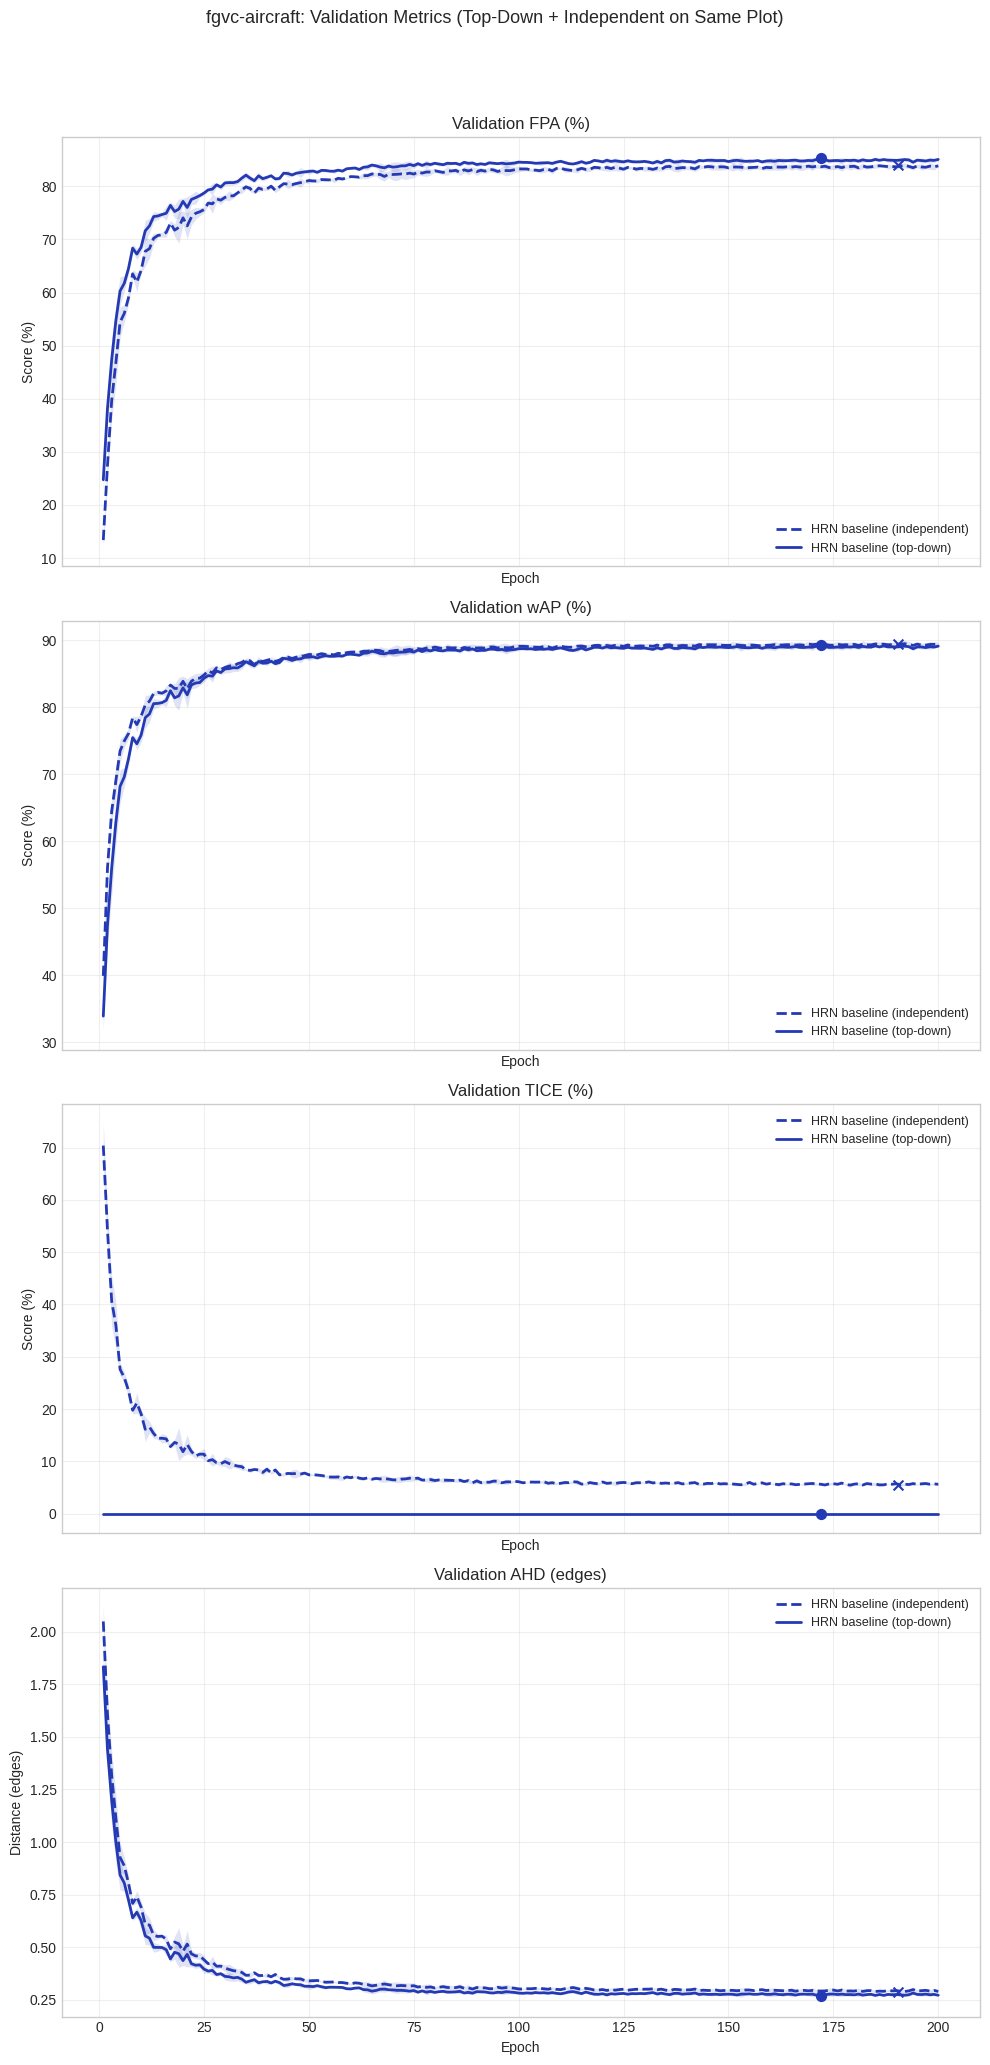

In [104]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate the effect of top-down decoding.
- Compare colors within a dataset to isolate the effect of each HRN training variant.

## HRN Consistency Diagnostics

This section uses HRN's logged level-2 projection/parent-consistency diagnostics when present:

- projection flip rate
- projection L1 delta
- ground-truth parent mass before and after projection

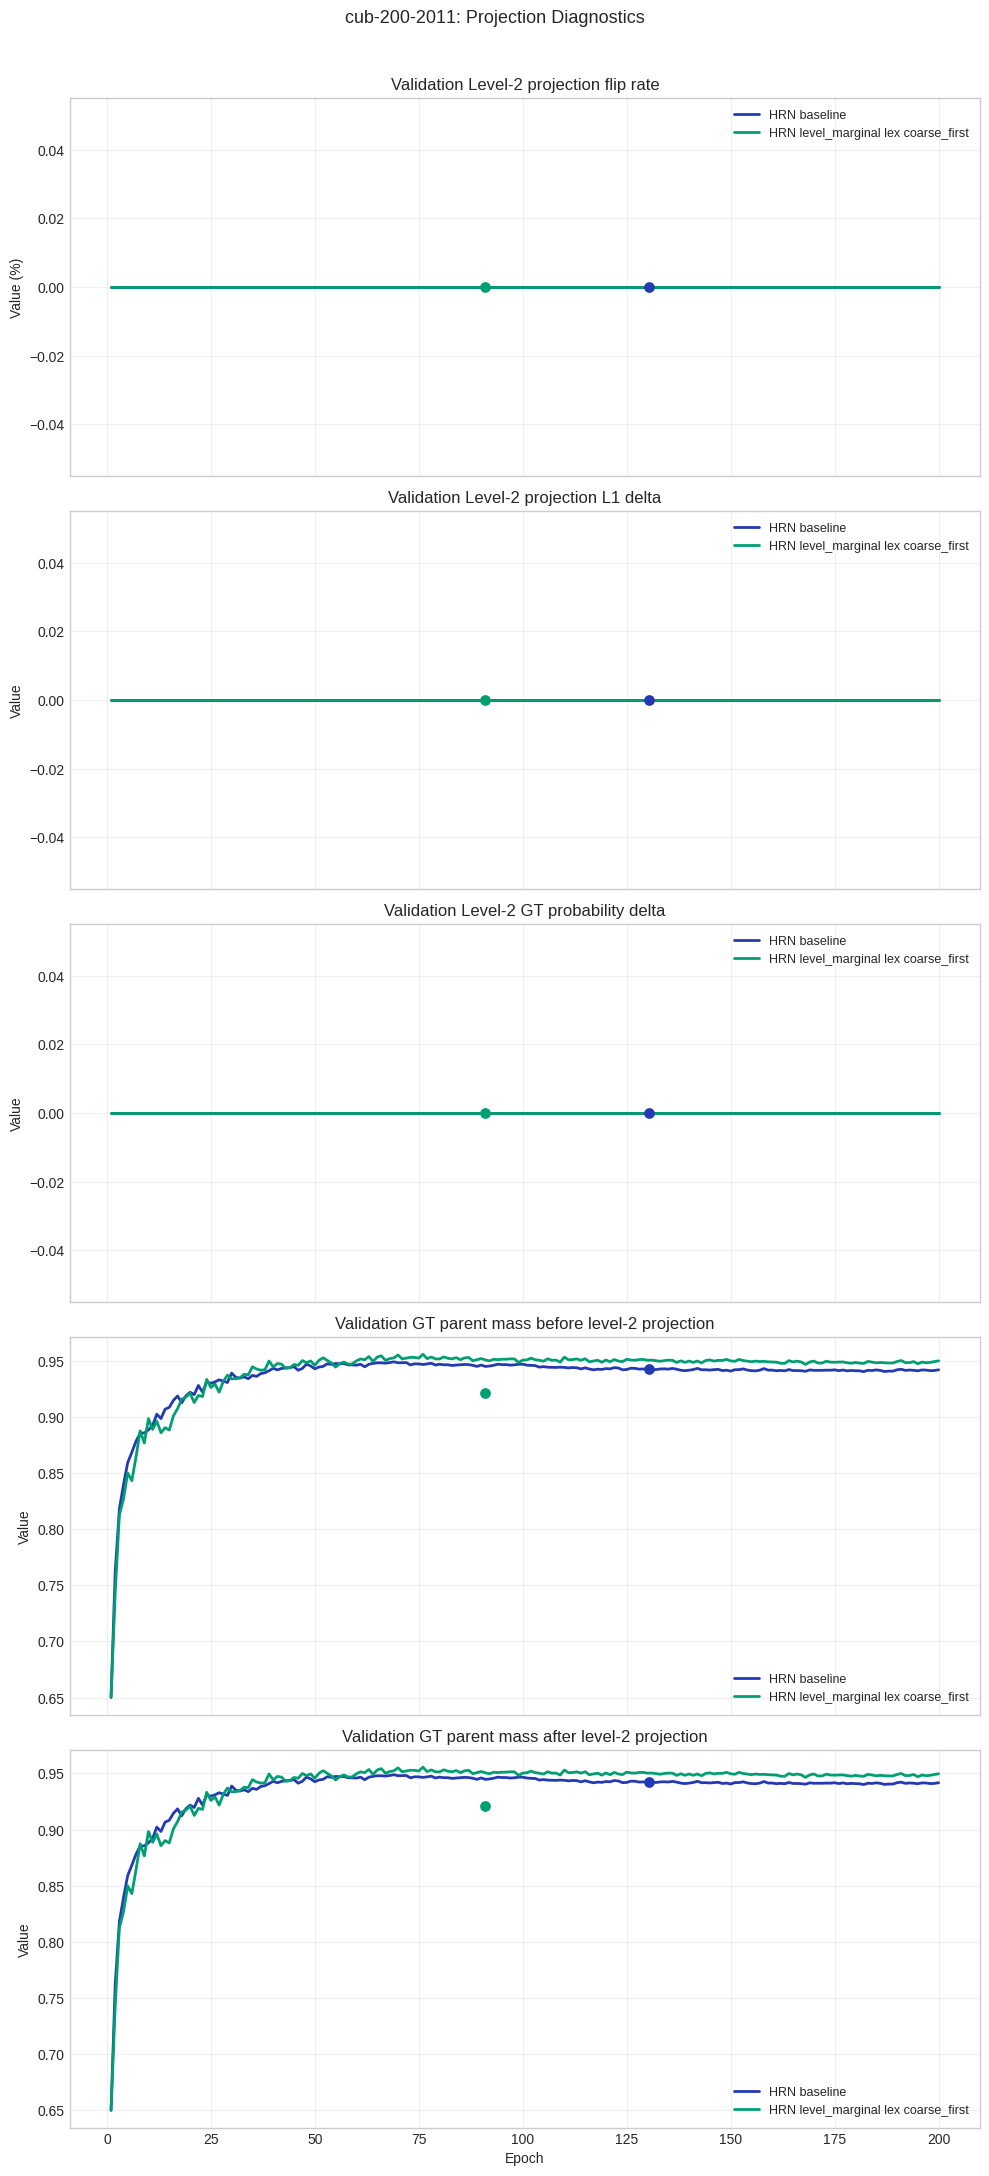

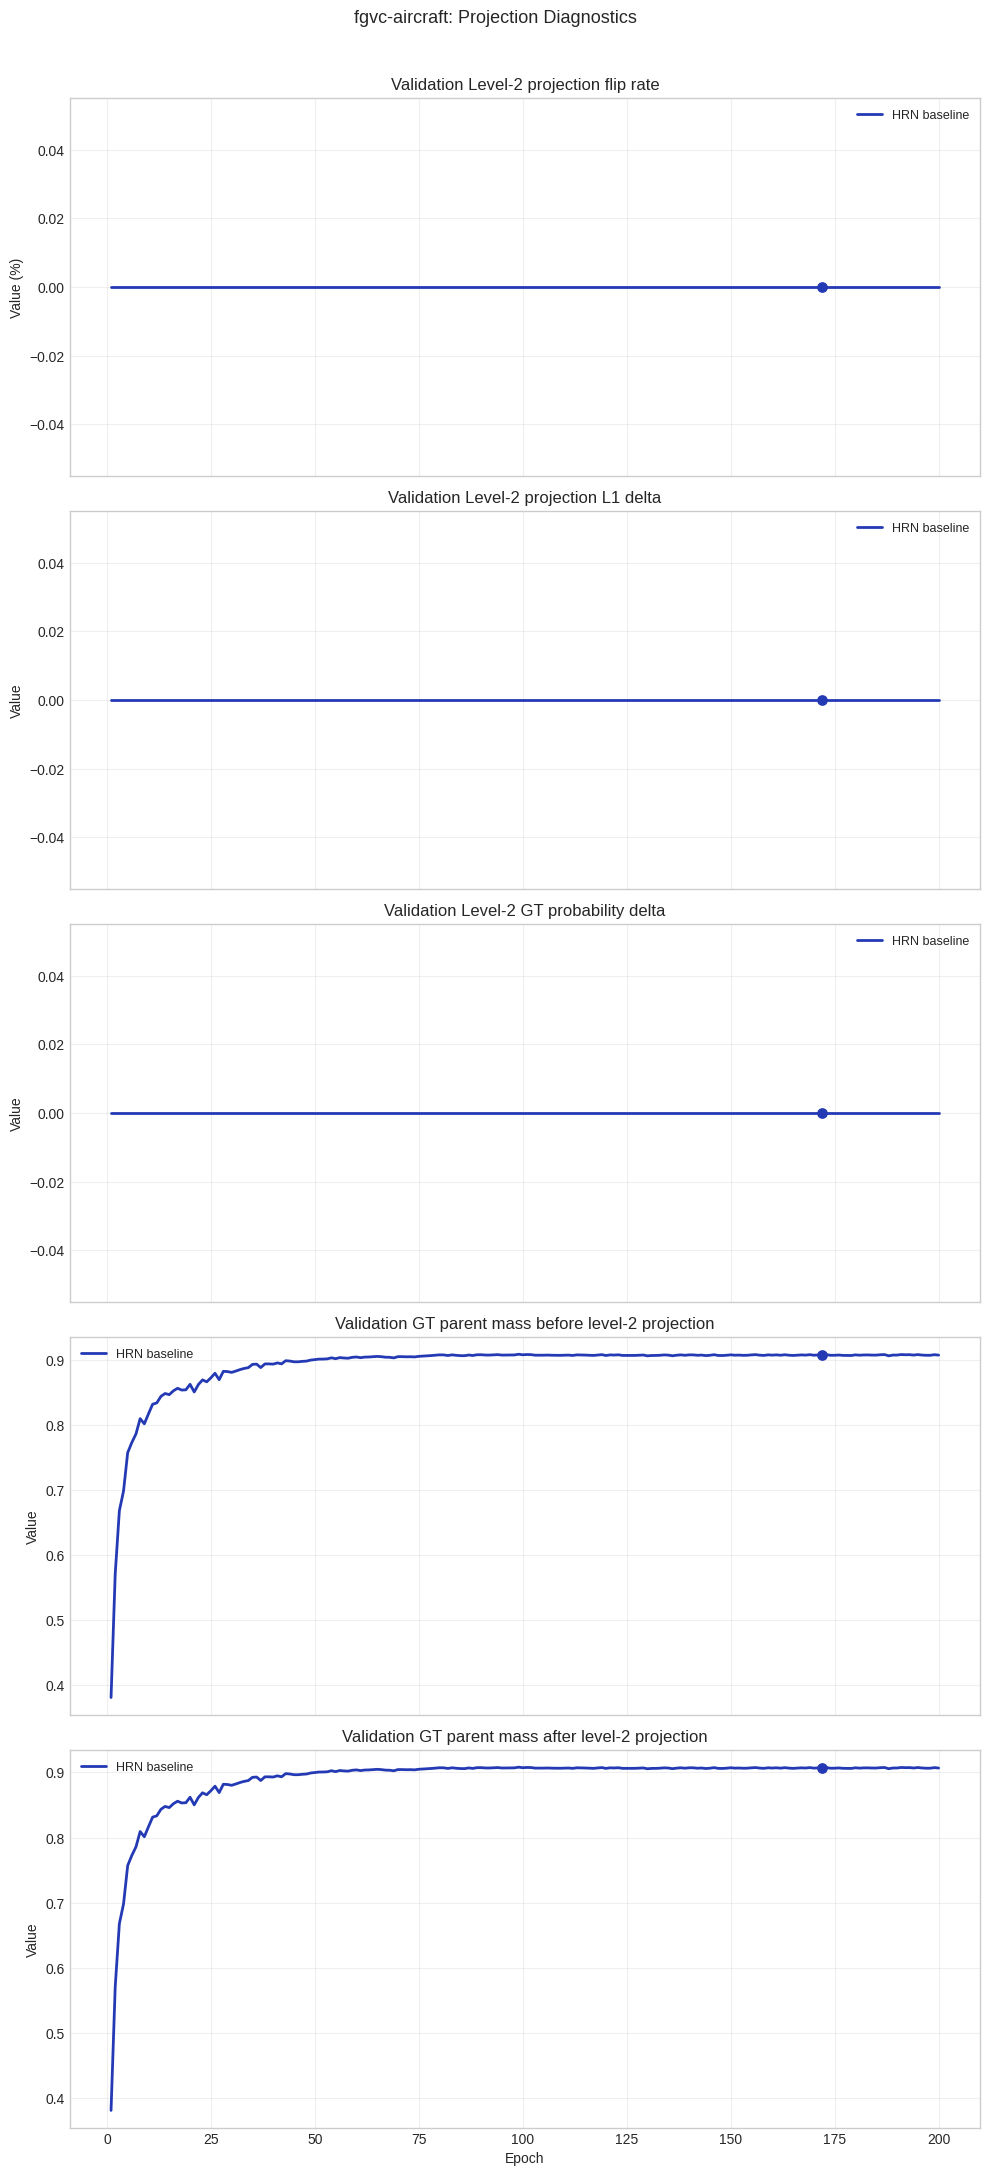

In [105]:
analysis.plot_projection_diagnostics(
    base_diag_specs=[
        ('proj_flip_rate_level_2', 'Level-2 projection flip rate', True, 'val'),
        ('proj_delta_l1_level_2', 'Level-2 projection L1 delta', False, 'val'),
        ('proj_gt_prob_delta_level_2', 'Level-2 GT probability delta', False, 'val'),
        ('gt_parent_mass_pre_l2', 'GT parent mass before level-2 projection', False, 'val'),
        ('gt_parent_mass_post_l2', 'GT parent mass after level-2 projection', False, 'val'),
    ]
)


## Training Loss Comparison

The HRN losses are `tree_loss`, `hier_loss`, `ce_loss_leaf`, and `fine_ce`.


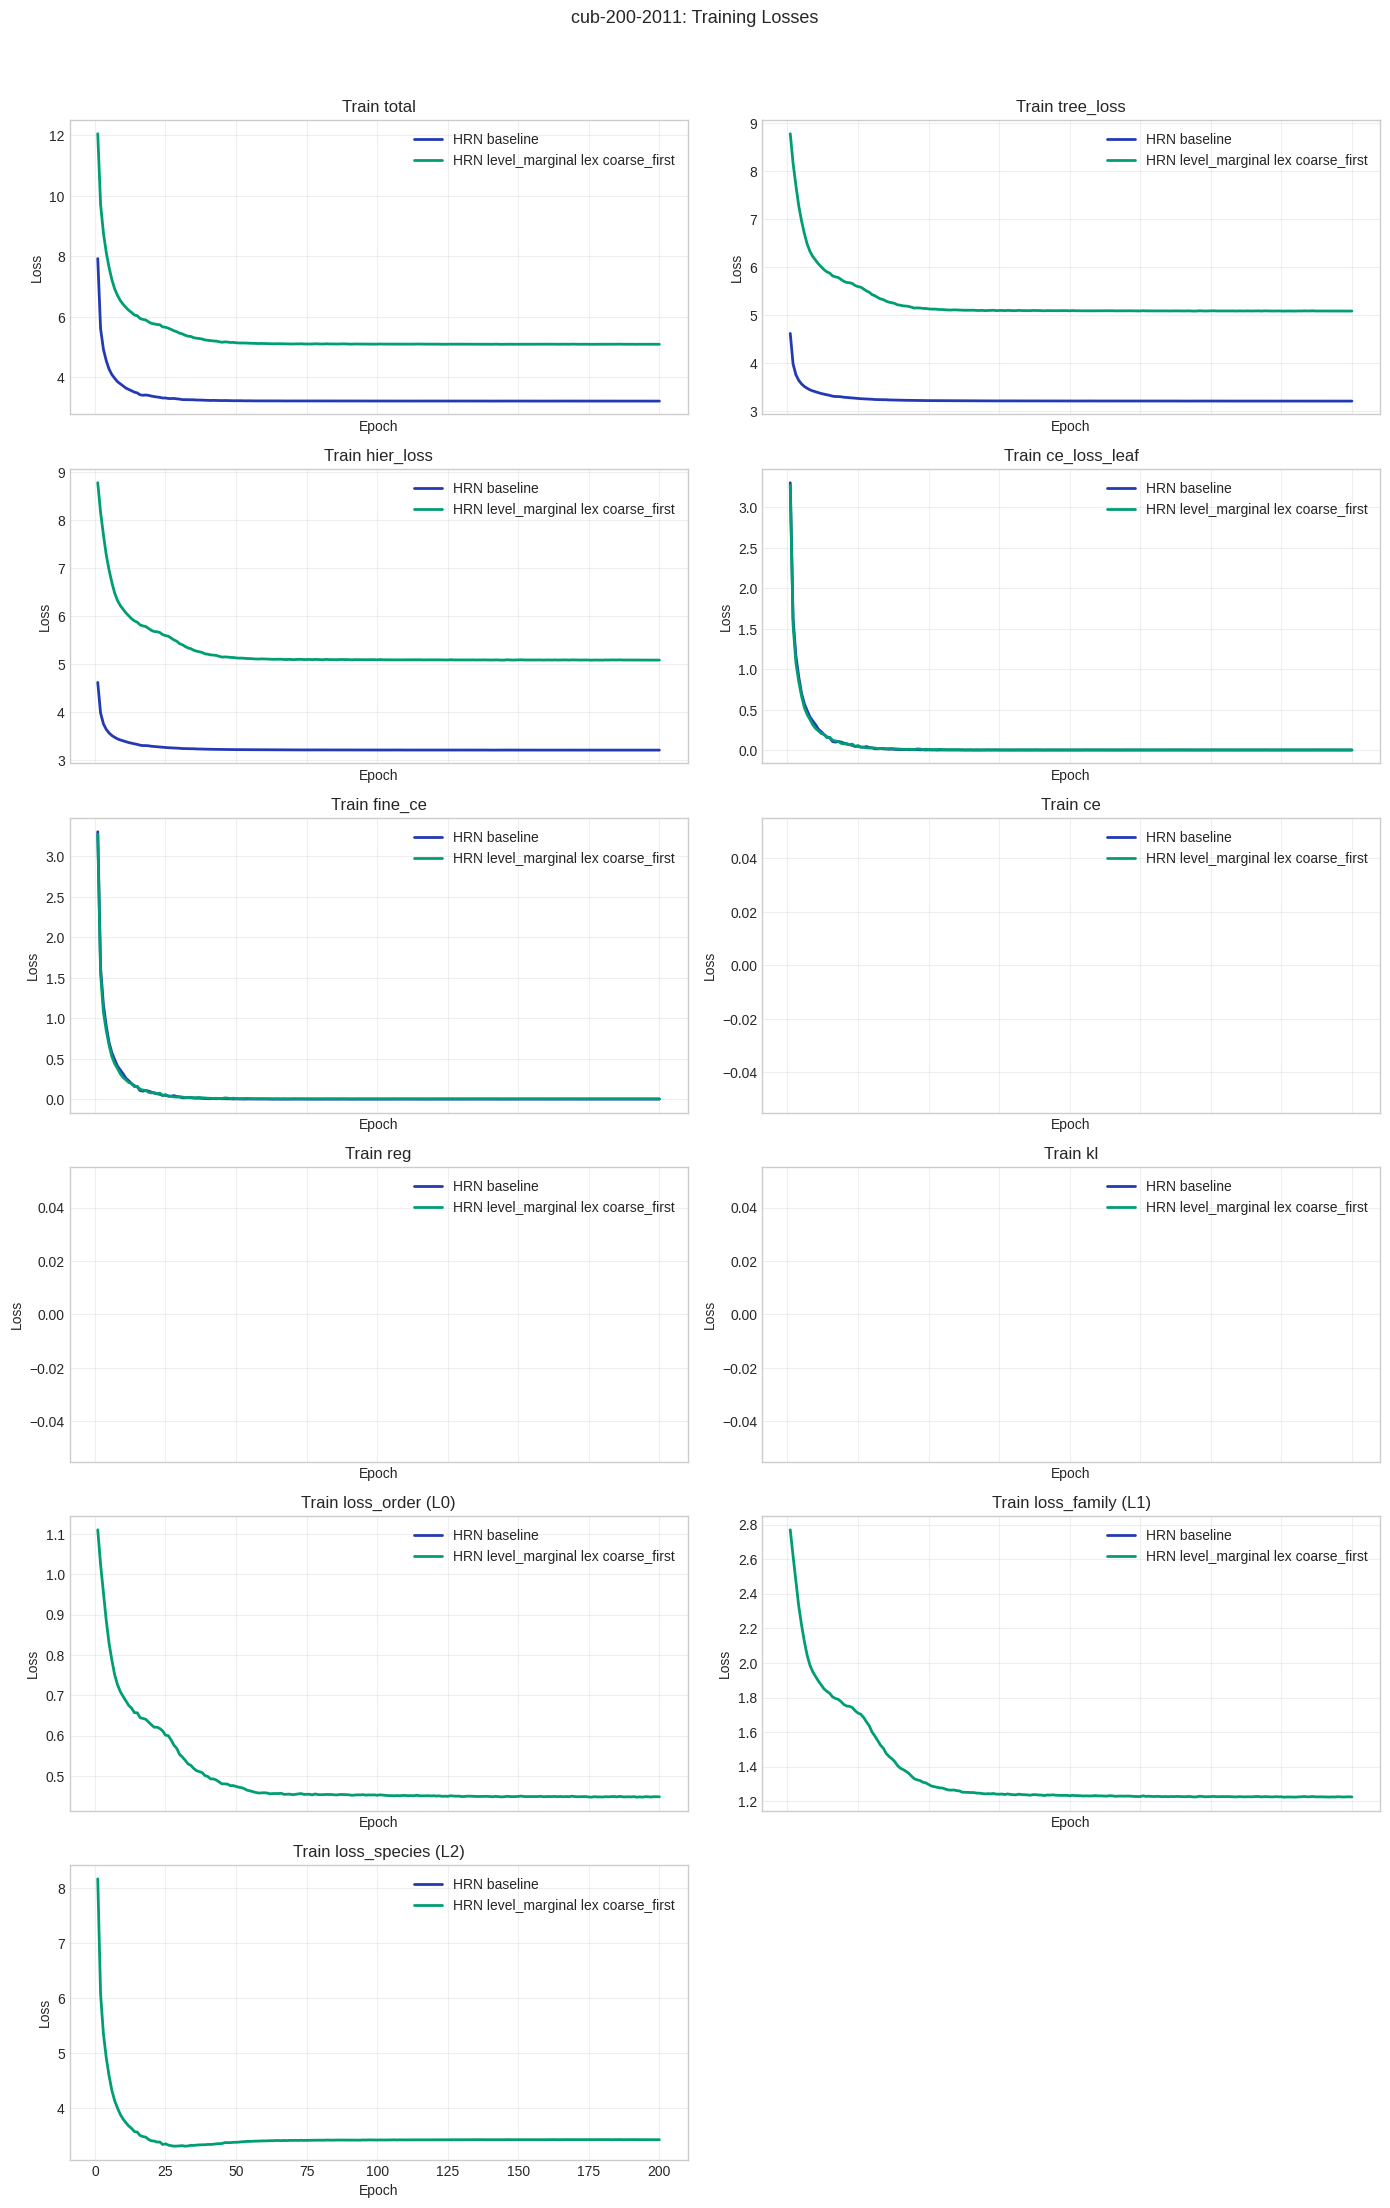

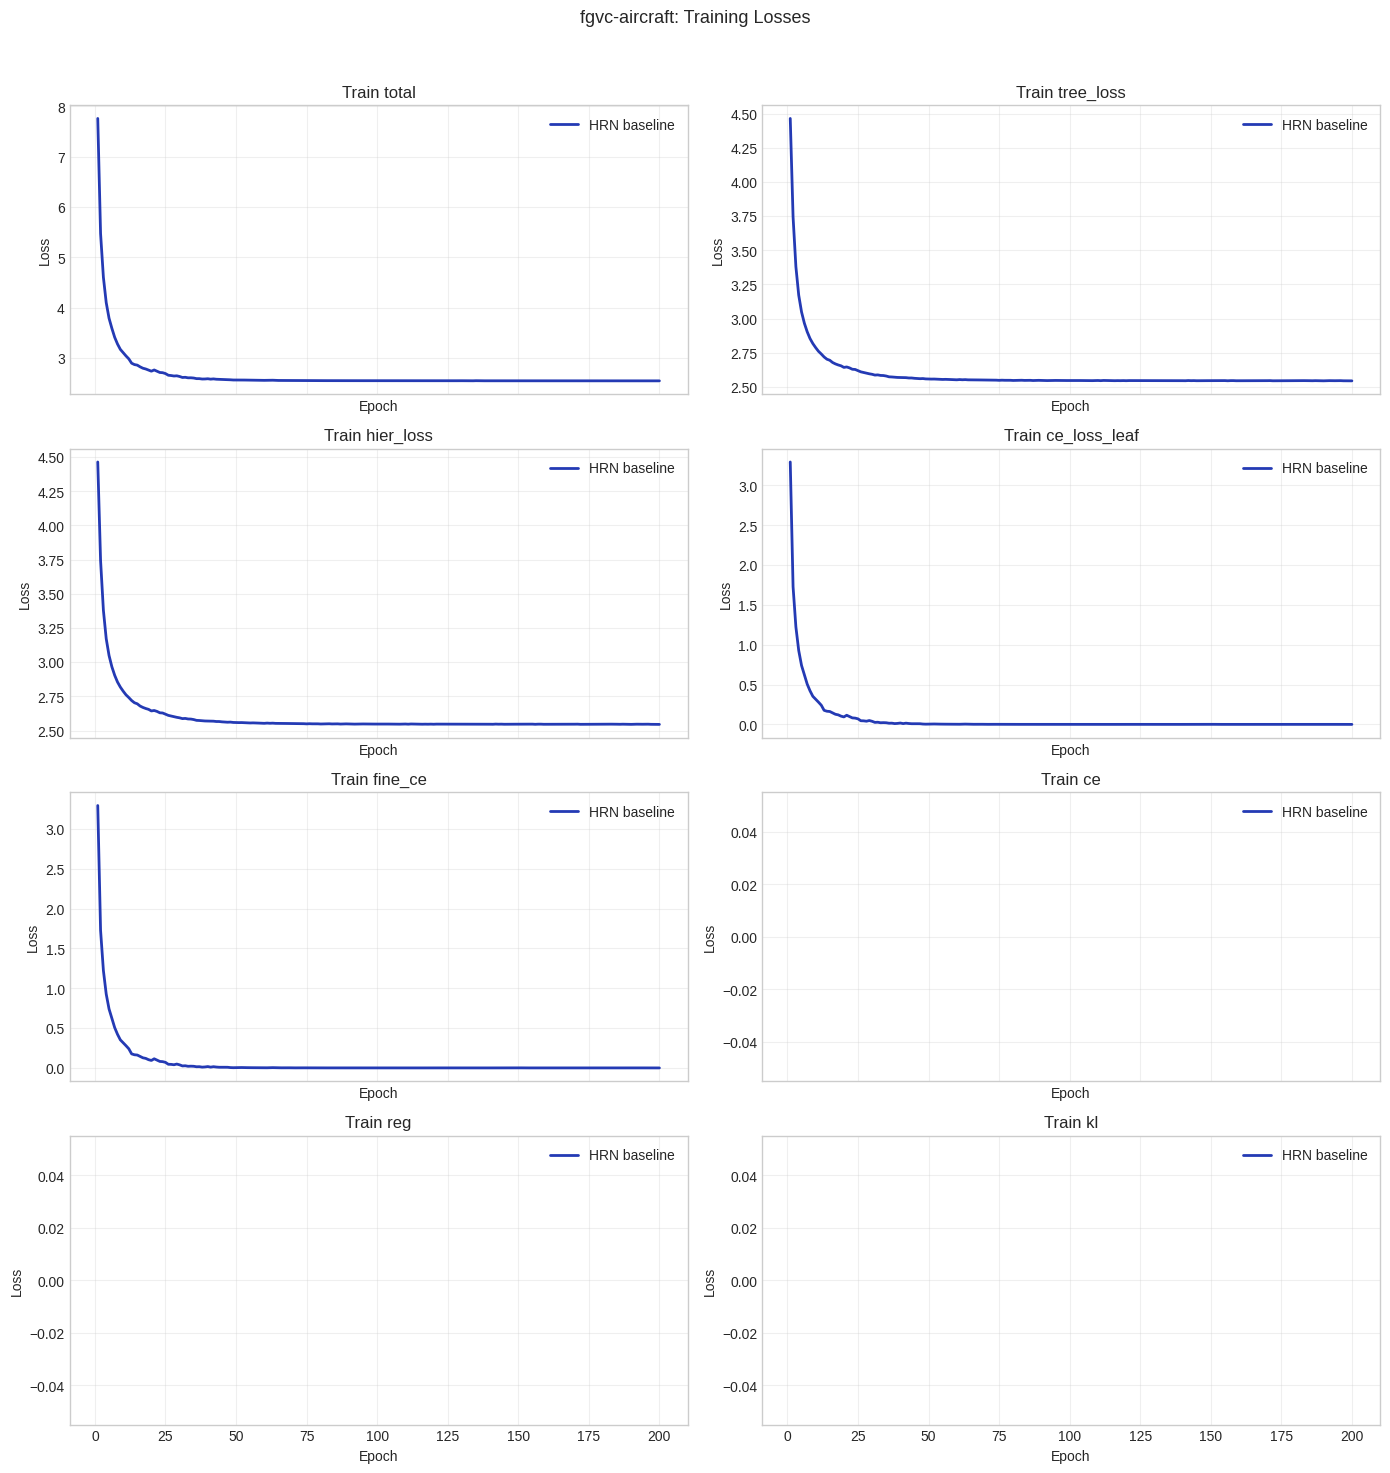

In [106]:
analysis.plot_training_losses(
    aggregate_loss_keys=['total', 'tree_loss', 'hier_loss', 'ce_loss_leaf', 'fine_ce', 'ce', 'reg', 'kl']
)


## Per-Run Per-Level Training Losses

This section shows the differentiable per-level terms emitted by compatible HRN training modes.


[cub-200-2011] No per-level train losses for HRN baseline


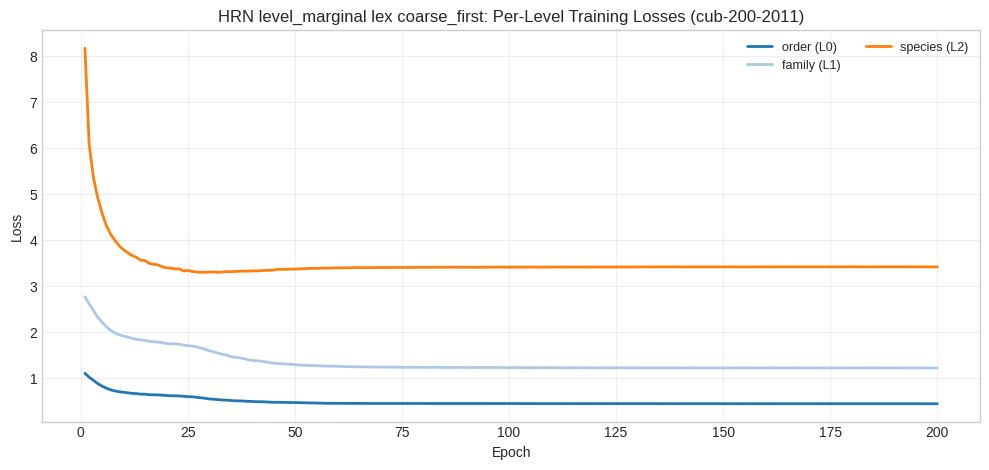

[fgvc-aircraft] No per-level train losses for HRN baseline


In [107]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

For the HRN non-lex runs used here, the main expected quantities are raw gradient norms/cosines and parameter movement diagnostics. No `post_*` lexicographic projection diagnostics are expected unless lexicographic training was enabled in a run.

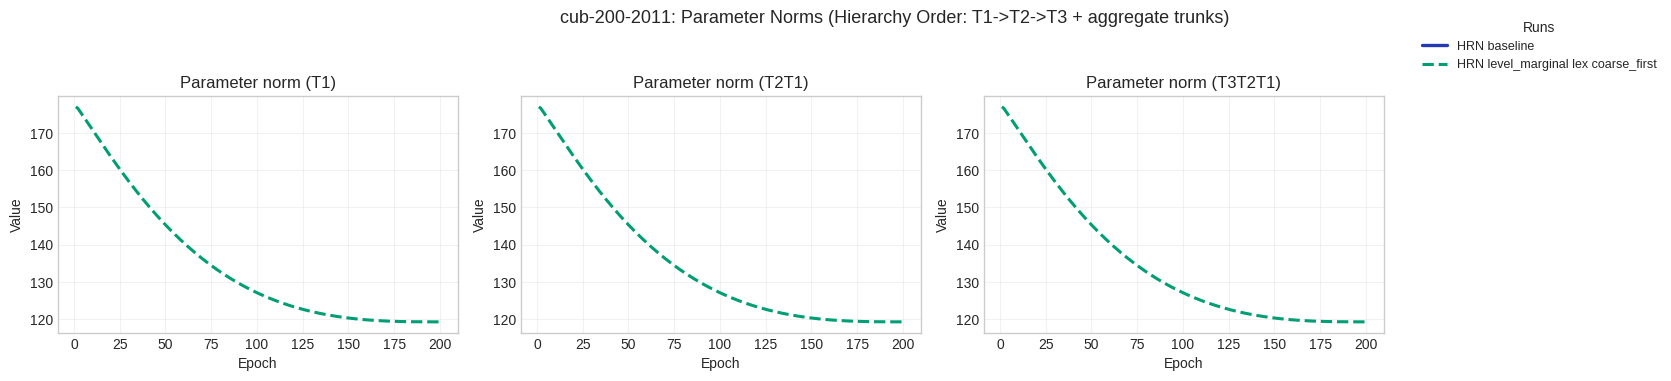

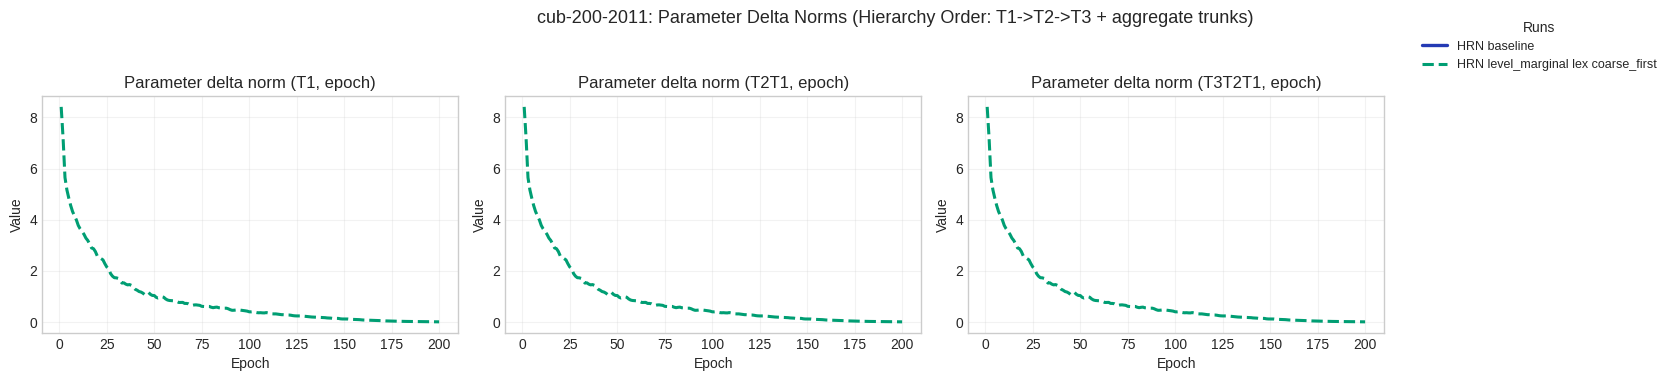

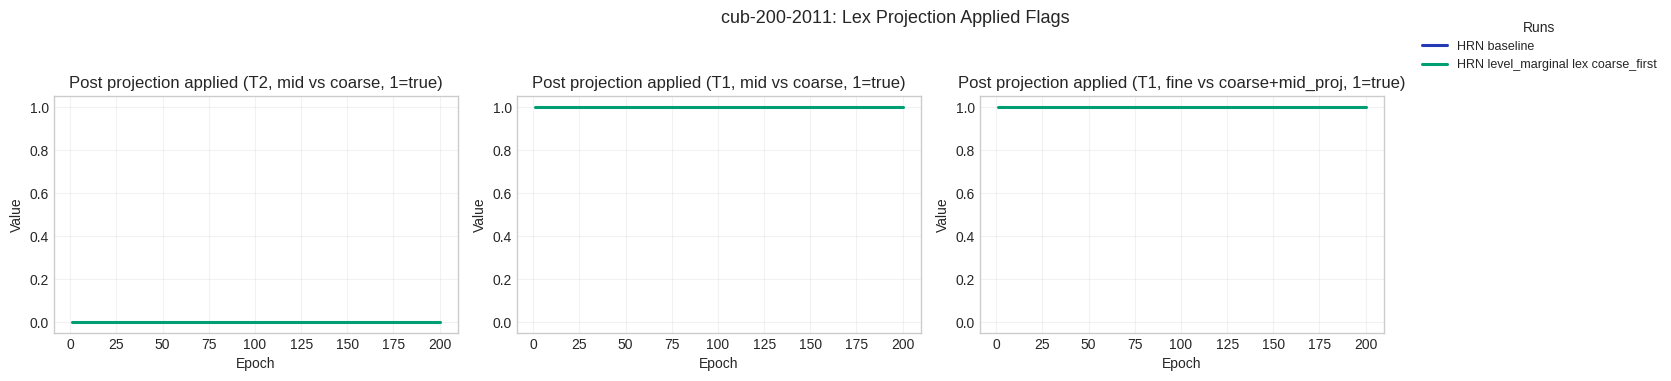

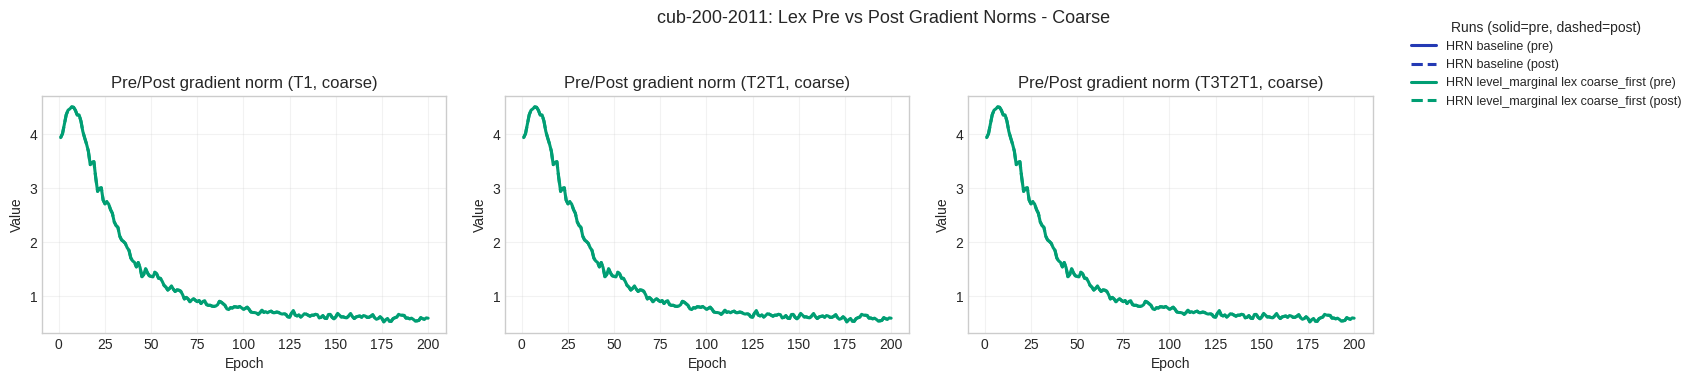

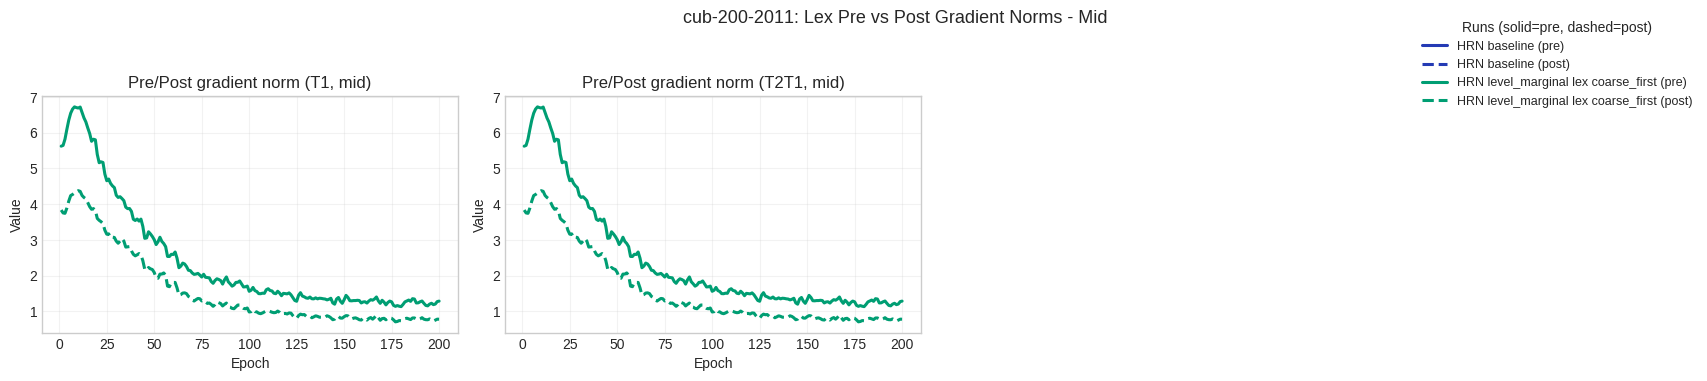

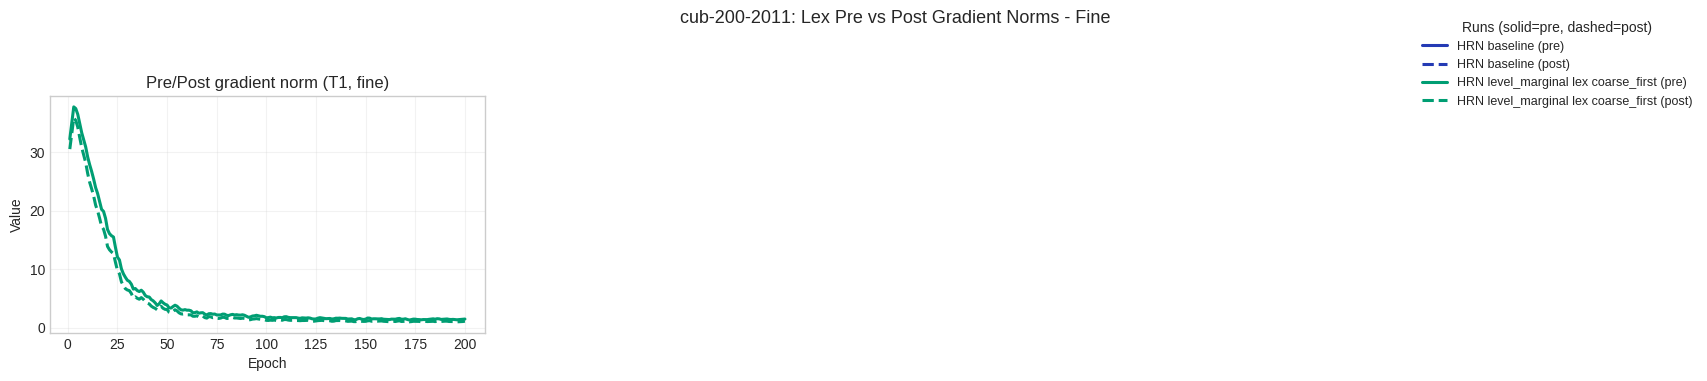

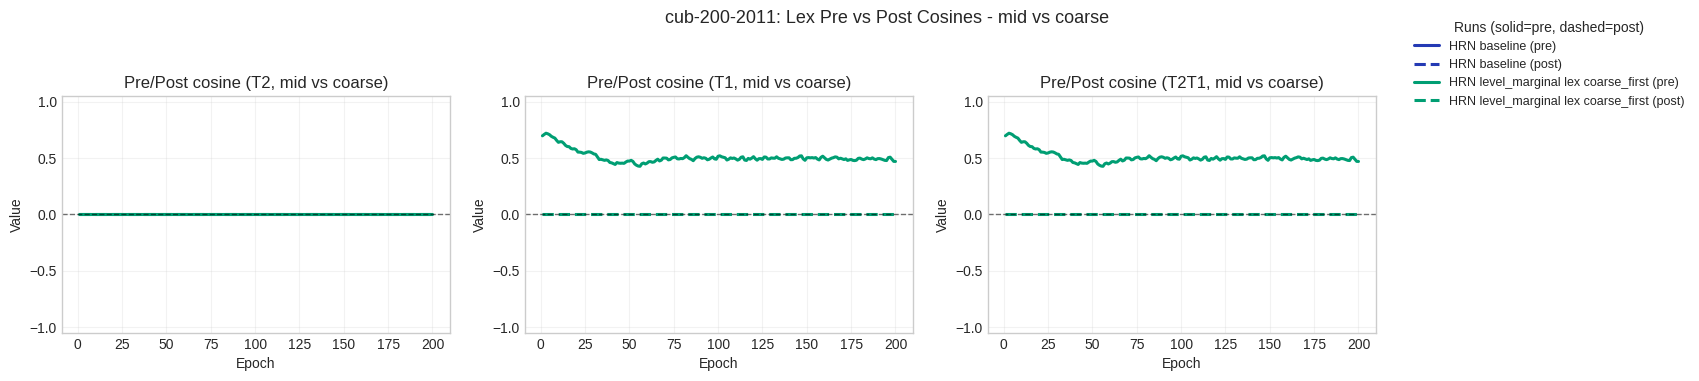

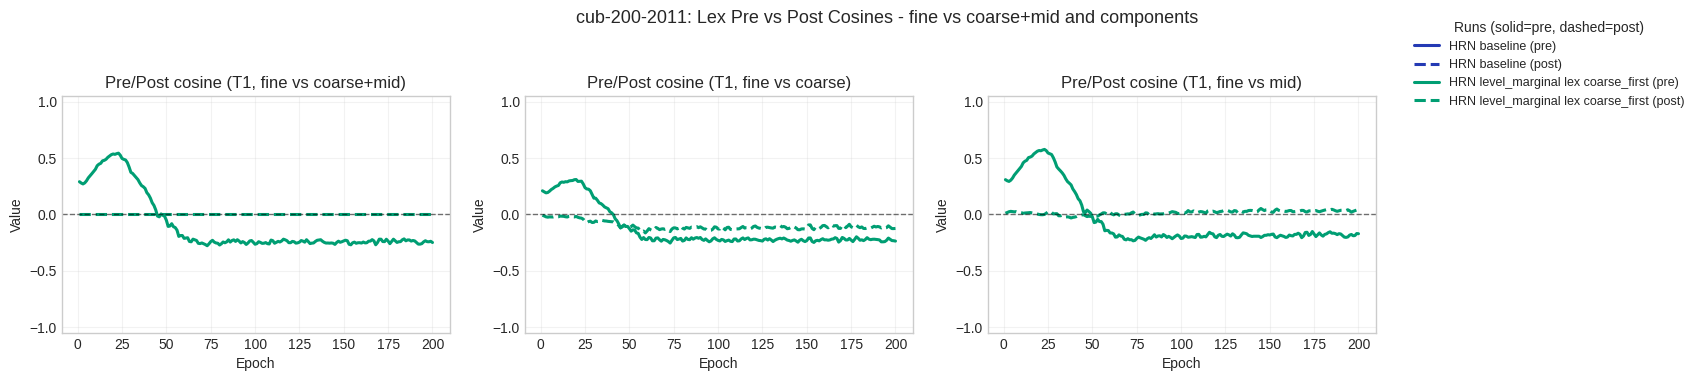

[fgvc-aircraft] No trunk gradient/parameter diagnostics found in selected runs.


In [108]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)

Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- Cosines near +1 indicate aligned objectives; cosines near -1 indicate conflict; cosines near 0 indicate near-orthogonal level gradients.
- For non-lex runs, compare raw diagnostics only; post-projection metrics are not part of the training update.

## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

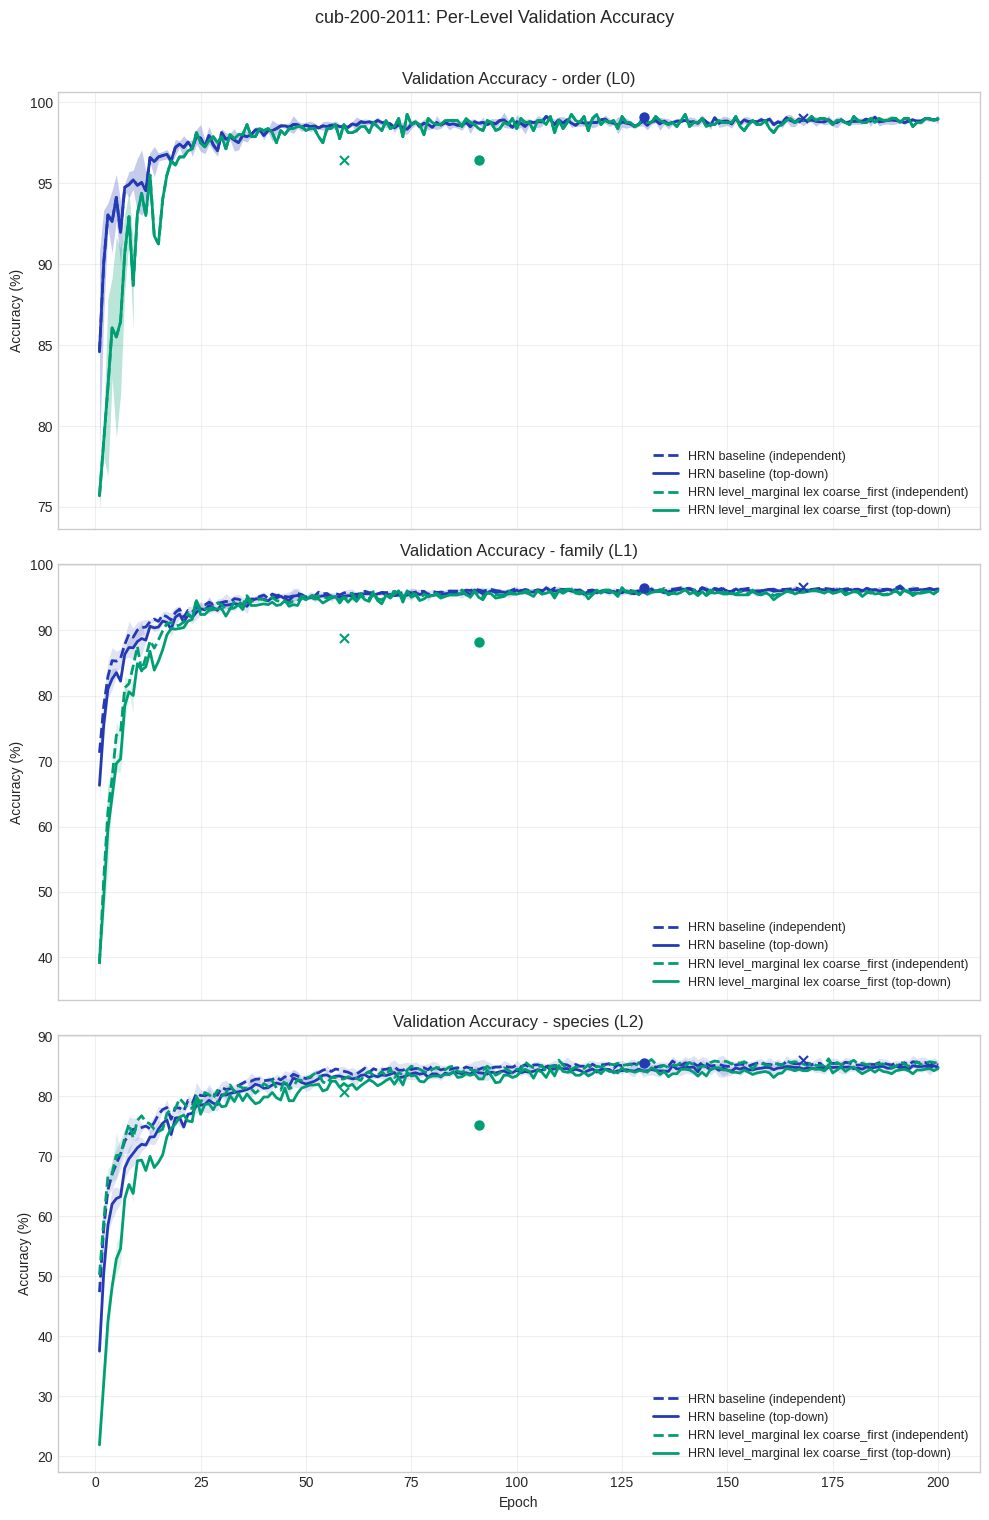

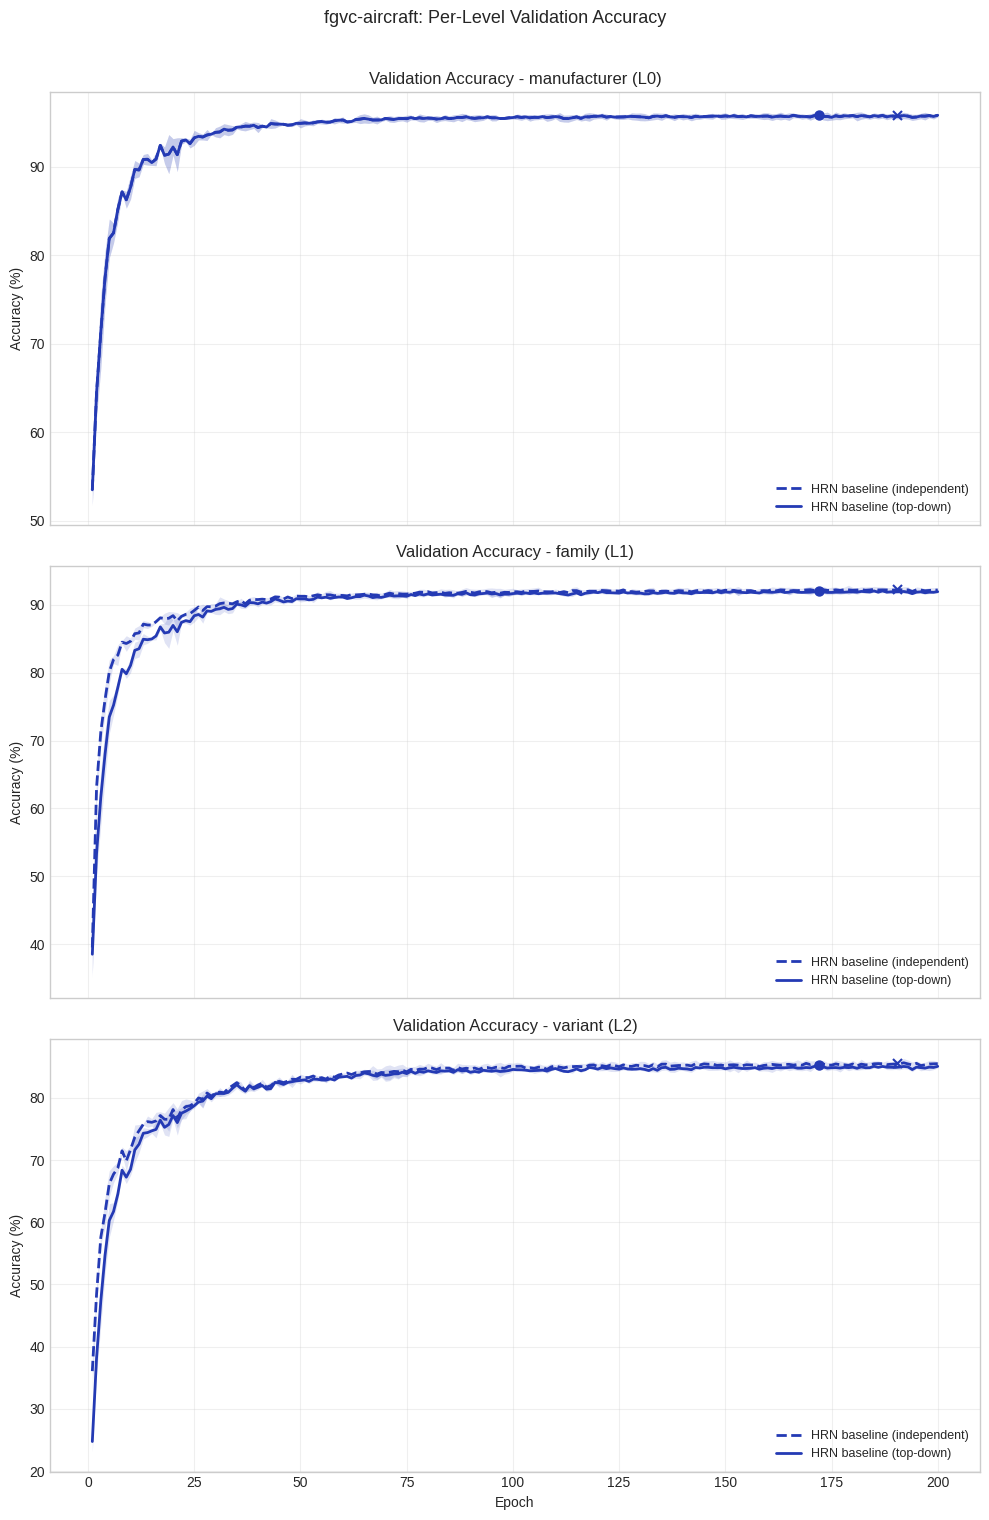

In [109]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected HRN runs and reports deltas versus the first run listed for that dataset.

In [110]:
analysis.show_final_test_tables()


### Dataset: `cub-200-2011`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) | HRN level_marginal lex coarse_first (n=2) |
|---|---:|---:|
| Best epoch (TD/Ind) | 130.3 ± 20.3/168.0 ± 25.5 | 174/110 |
| FPA independent ↑ | **84.15% ± 0.37%** | <u>83.29% (-0.86 pp)</u> |
| FPA top-down ↑ | **85.03% ± 0.17%** | <u>84.09% (-0.94 pp)</u> |
| wAP independent ↑ | **87.90% ± 0.20%** | <u>87.47% (-0.43 pp)</u> |
| wAP top-down ↑ | **87.29% ± 0.13%** | <u>86.42% (-0.87 pp)</u> |
| TICE independent ↓ | <u>4.05% ± 0.09%</u> | **4.00% (-0.05 pp)** |
| TICE top-down ↓ | **0.00% ± 0.00%** | **0.00% (+0.00 pp)** |
| AHD independent ↓ | **0.222 ± 0.004** | <u>0.236 (+0.014)</u> |
| AHD top-down ↓ | **0.209 ± 0.002** | <u>0.227 (+0.018)</u> |
| Acc independent order (L0) ↑ | **98.76% ± 0.08%** | <u>98.57% (-0.19 pp)</u> |
| Acc top-down order (L0) ↑ | **98.81% ± 0.03%** | <u>98.62% (-0.19 pp)</u> |
| Acc independent family (L1) ↑ | **95.29% ± 0.06%** | <u>94.87% (-0.41 pp)</u> |
| Acc top-down family (L1) ↑ | **95.24% ± 0.07%** | <u>94.55% (-0.70 pp)</u> |
| Acc independent species (L2) ↑ | **85.79% ± 0.25%** | <u>85.35% (-0.44 pp)</u> |
| Acc top-down species (L2) ↑ | **85.03% ± 0.17%** | <u>84.09% (-0.94 pp)</u> |

### Dataset: `fgvc-aircraft`
Baseline run: **HRN baseline**

| Metric | HRN baseline (n=3) |
|---|---:|
| Best epoch (TD/Ind) | 172.0 ± 25.2/190.3 ± 10.6 |
| FPA independent ↑ | 84.77% ± 0.06% |
| FPA top-down ↑ | 86.06% ± 0.22% |
| wAP independent ↑ | 90.20% ± 0.16% |
| wAP top-down ↑ | 89.83% ± 0.14% |
| TICE independent ↓ | 5.33% ± 0.45% |
| TICE top-down ↓ | 0.00% ± 0.00% |
| AHD independent ↓ | 0.273 ± 0.004 |
| AHD top-down ↓ | 0.253 ± 0.004 |
| Acc independent manufacturer (L0) ↑ | 96.09% ± 0.06% |
| Acc top-down manufacturer (L0) ↑ | 96.06% ± 0.12% |
| Acc independent family (L1) ↑ | 92.93% ± 0.33% |
| Acc top-down family (L1) ↑ | 92.55% ± 0.18% |
| Acc independent variant (L2) ↑ | 86.53% ± 0.08% |
| Acc top-down variant (L2) ↑ | 86.06% ± 0.22% |